# Agentic AI MCP - Client Only

This notebook connects to a remote MCP server and runs agentic workflows.
The MCP server should be running on another machine (see `quickstart_server.ipynb`).

## Step 1: Setup

In [ ]:
# install if needed
# !uv pip install agentic-ai-mcp==0.6.2

import agentic_ai_mcp

print(f"Version: {agentic_ai_mcp.__version__}")

## Step 2: Make Sure To Have A Valid API_KEY

The LLM runs on this machine, so you need the API key here.
- For **Anthropic** (default): Set `ANTHROPIC_API_KEY`
- For **OpenAI**: Set `OPENAI_API_KEY`

In [ ]:
import os

from dotenv import load_dotenv

load_dotenv()

# check for API keys
if os.getenv("ANTHROPIC_API_KEY"):
    print("ANTHROPIC_API_KEY is set")
else:
    print("WARNING: ANTHROPIC_API_KEY not found")

if os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY is set")
else:
    print("INFO: OPENAI_API_KEY not found (optional, only needed for OpenAI provider)")

## Step 3: Connect to MCP Server and Create AgenticAIClient

Use the `mcp_url` parameter to connect to an existing MCP server.

In [3]:
from agentic_ai_mcp import AgenticAIClient

# connect to MCP server (change this to your server's URL)
MCP_SERVER_URL = "http://127.0.0.1:8888/mcp"

# default: provider = 'anthropic', model = 'claude-haiku-4-5-20251001'
client = AgenticAIClient(mcp_url=MCP_SERVER_URL, verbose=True)

# if you want to use OpenAI model, change accordingly, e.g. -
# client = AgenticAIClient(mcp_url=MCP_SERVER_URL, provider="openai", model="gpt-4o-mini")

# you can also pass the API key directly:
# client = AgenticAIClient(mcp_url=MCP_SERVER_URL, api_key="sk-...")

print(f"Client configured to connect to: {MCP_SERVER_URL}")

Client configured to connect to: http://127.0.0.1:8888/mcp


## Step 4a: Run Agent (Simple Task)

In [4]:
result = await client.run("Calculate 2+1, then use the result as the number of times to greet 'Alice'.")
print()
print(">>>")
print()
print(result)

Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['add', 'multiply', 'greet', 'do_imaging']

PROMPT: Calculate 2+1, then use the result as the number of times to greet 'Alice'.



/mnt/jawad_cnms_s1/jawad_server/code/20260221_code_agentic_ai/agentic-ai-mcp/src/agentic_ai_mcp/client.py:165: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  self._agent = create_react_agent(


STEP 1: add({'a': 2, 'b': 1})
  → 3

STEP 2: greet({'name': 'Alice', 'times': 3})
  → Hello, Alice! Hello, Alice! Hello, Alice! 

RESULT: Perfect! The calculation 2+1 equals 3, and Alice has been greeted 3 times: "Hello, Alice! Hello, Alice! Hello, Alice!"


>>>

Perfect! The calculation 2+1 equals 3, and Alice has been greeted 3 times: "Hello, Alice! Hello, Alice! Hello, Alice!"


## Step 4b: Run Agent (Simple Task with Image Generation)

The server generates an image which is automatically displayed in Jupyter.


PROMPT: Generate a 100x100 random image using do_imaging

STEP 1: do_imaging({'width': 100, 'height': 100})
  → Generated a 100x100 random image

RESULT: Perfect! I've generated a 100x100 random image using the `do_imaging` function. The image has been created with the specified dimensions of 100 pixels by 100 pixels.



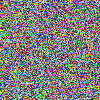

[Displayed 100x100 image]

>>>

Perfect! I've generated a 100x100 random image using the `do_imaging` function. The image has been created with the specified dimensions of 100 pixels by 100 pixels.


In [5]:
result = await client.run("Generate a 100x100 random image using do_imaging")
print()
print(">>>")
print()
print(result)

## Step 4c: Run Agent (Complex Task with Planning)


PLANNING MODE
TASK: Calculate (((0+2) x (1+1)) + ((0+1) x (1+1))) + 250, then use the result as the height and width of an image to do imaging.

PLAN:
  1. Use add(a=0, b=2) to calculate the first sum
  2. Use add(a=1, b=1) to calculate the second sum
  3. Use multiply(a=result from step 1, b=result from step 2) to get the first product
  4. Use add(a=0, b=1) to calculate the third sum
  5. Use add(a=1, b=1) to calculate the fourth sum
  6. Use multiply(a=result from step 4, b=result from step 5) to get the second product
  7. Use add(a=result from step 3, b=result from step 6) to add the two products
  8. Use add(a=result from step 7, b=250) to add 250 to get the final dimension value
  9. Use do_imaging(width=result from step 8, height=result from step 8) to generate an image with the calculated dimensions

EXECUTING STEP 1/9: Use add(a=0, b=2) to calculate the first sum
----------------------------------------


/mnt/jawad_cnms_s1/jawad_server/code/20260221_code_agentic_ai/agentic-ai-mcp/src/agentic_ai_mcp/workflows/planning.py:151: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  step_agent = create_react_agent(llm, tools)


  TOOL CALL 1: add({'a': 0, 'b': 2})
    → 2
  AI RESPONSE: The first sum is **2** (0 + 2 = 2).
----------------------------------------
STEP 1 COMPLETE

EXECUTING STEP 2/9: Use add(a=1, b=1) to calculate the second sum
----------------------------------------
  TOOL CALL 1: add({'a': 1, 'b': 1})
    → 2
  AI RESPONSE: **Step 2: The second sum is 2** (1 + 1 = 2).

So far:
- Step 1: 0 + 2 = **2**
- Step 2: 1 + 1 = **2**
----------------------------------------
STEP 2 COMPLETE

EXECUTING STEP 3/9: Use multiply(a=result from step 1, b=result from step 2) to get the first product
----------------------------------------
  TOOL CALL 1: multiply({'a': 2, 'b': 2})
    → 4
  AI RESPONSE: Perfect! **The first product is 4** (2 × 2 = 4).

**Summary so far:**
- Step 1: 0 + 2 = **2**
- Step 2: 1 + 1 = **2**
- Step 3 (Current): 2 × 2 = **4** ✓
----------------------------------------
STEP 3 COMPLETE

EXECUTING STEP 4/9: Use add(a=0, b=1) to calculate the third sum
----------------------------------

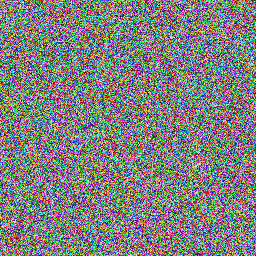

[Displayed 256x256 image]

>>>

# Final Response

## Task Completed Successfully ✓

**Calculation Result:** 256

Breaking down the original expression:
- (0+2) × (1+1) = 2 × 2 = **4**
- (0+1) × (1+1) = 1 × 2 = **2**
- 4 + 2 + 250 = **256**

**Image Generated:** A 256 × 256 pixel image has been created using the calculated dimensions as both width and height.

The mathematical steps progressed logically from basic arithmetic operations through multiplication and addition, culminating in a final dimension value of **256 pixels**, which was then applied to generate the image as requested.


In [6]:
result = await client.run_with_planning("Calculate (((0+2) x (1+1)) + ((0+1) x (1+1))) + 250, then use the result as the height and width of an image to do imaging.")
print()
print(">>>")
print()
print(result)